# TS3 - Simulación de un ADC

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

## Generador de señales (de TS1)

In [2]:
class GeneradorSenales:

    @staticmethod
    def _generar_tiempo(n, fs):
        return (np.arange(n) / fs).reshape(-1, 1)

    @staticmethod
    def generar_seno(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):
        tt = GeneradorSenales._generar_tiempo(n, fs)
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx

    @staticmethod
    def generate_noisy_signal(clean, sigma=1):
        """
        Genera una medición ruidosa: x = clean + w
        """
        noise = np.random.normal(loc=0.0, scale=sigma, size=clean.shape)
        return clean + noise


## Cuantizador

Implementamos un cuantizador *mid-tread* (incluye el nivel cero) con redondeo al nivel más cercano y saturación a $\pm V_F$:

$$q = \frac{V_{FS}}{2^B} = \frac{2\,V_F}{2^B}$$

luego saturado al rango $[-V_F,\, V_F]$.

In [3]:
def cuantizar(sR, B, Vf):
    """
    Parametros
    ----------
    sR : array_like
        Senial de entrada .
    B : int
        Cantidad de bits del ADC.
    Vf : float
        Tension de fondo de escala (rango total Vfs = 2*Vf).

    Returns
    -------
    sQ : ndarray
        Senial cuantizada
    q : float
        Paso de cuantizacion.
    """
    sR_in = np.asarray(sR, dtype=float)
    q = (2.0 * Vf) / (2 ** B)

    sQ = q * np.round(sR_in / q)
    sQ = np.clip(sQ, -Vf, Vf)

    return sQ, q

## Señal de prueba

Senoidal con potencia unitaria ($A =\sqrt(2)$)

In [4]:
N = 1000
fs = 1000
f0 = fs / N
A = np.sqrt(2)

tt, sR = GeneradorSenales.generar_seno(vmax=A, ff=f0, n=N, fs=fs)

print(f"Potencia: {np.mean(sR**2):.4f}   (esperada: 1.0)")

Potencia: 1.0000   (esperada: 1.0)


## Comparación visual: $s_R$ vs $s_Q$ para $V_F = 2$ V y $B \in \{4, 8, 16\}$

Los tres gráficos comparten el mismo eje en Volts ($\pm V_F$) para que se vea cómo, al aumentar $B$, los escalones del cuantizador se acercan a la señal original.

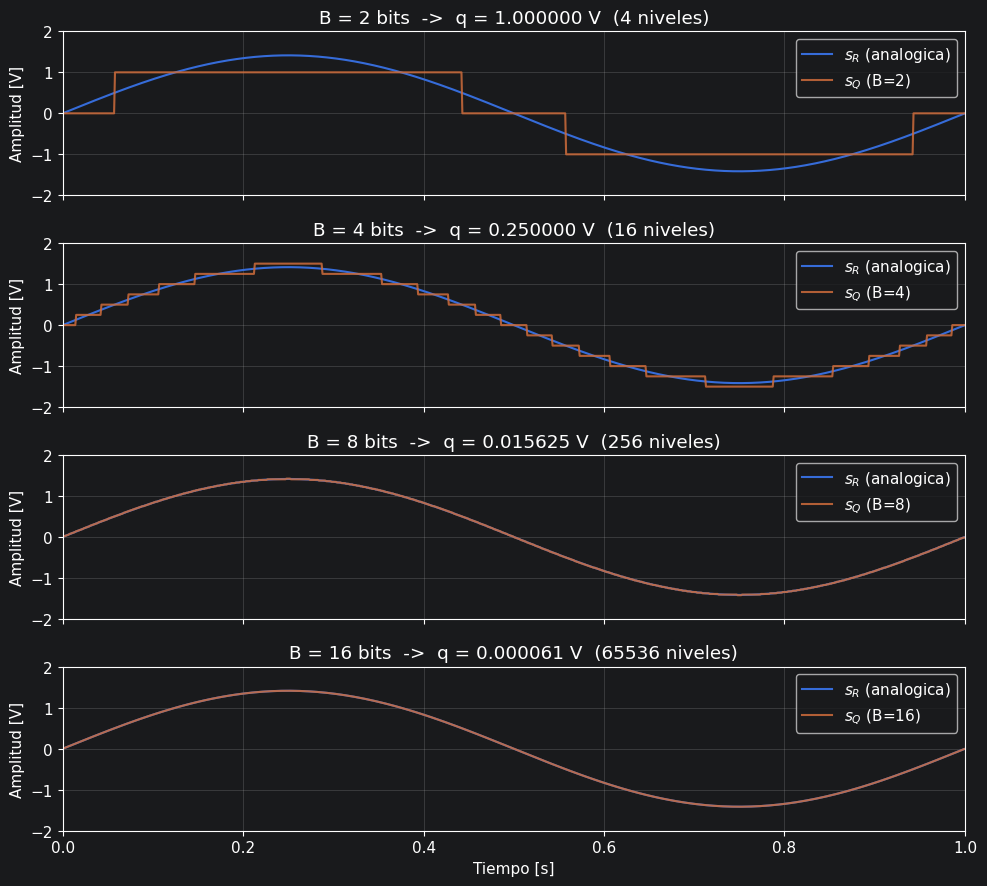

In [5]:
Vf = 2.0
Bs = [2, 4, 8, 16]

fig, axes = plt.subplots(len(Bs), 1, figsize=(10, 9), sharex=True)

for ax, B in zip(axes, Bs):
    sQ, q = cuantizar(sR, B, Vf)

    ax.plot(tt, sR, label="$s_R$ (analogica)", linewidth=1.5)
    ax.plot(tt, sQ, label=f"$s_Q$ (B={B})", linewidth=1.5, alpha=0.85)
    ax.set_ylim(-Vf, Vf)
    ax.set_ylabel("Amplitud [V]")
    ax.set_title(f"B = {B} bits  ->  q = {q:.6f} V  ({2**B} niveles)")
    ax.legend(loc="upper right")
    ax.set_xlim(tt[0], tt[0] + 1/f0)

axes[-1].set_xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

Como en 0 la pendiente del seno es maxima, el mayor error se producira en esa zona. Se hace un zoom para visualizar que en 16 bits es inperceptible

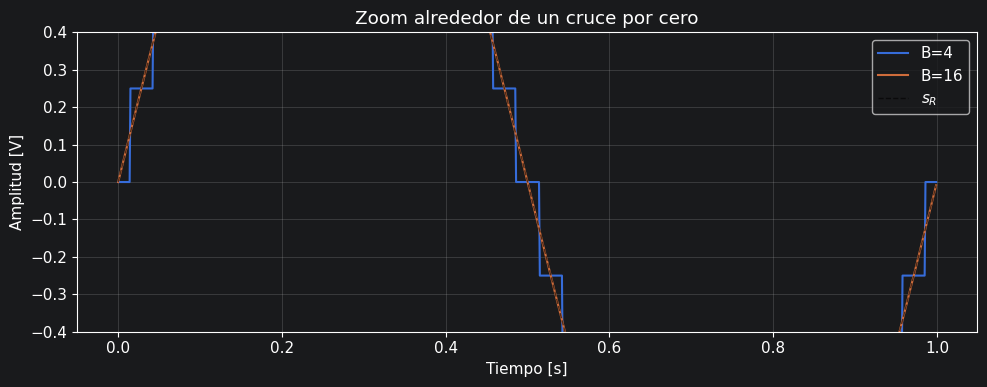

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

for B in [4, 16]:
    sQ, q = cuantizar(sR, B, Vf)
    ax.plot(tt, sQ, label=f"B={B}", linewidth=1.5)

ax.plot(tt, sR, "k--", label="$s_R$", linewidth=1, alpha=0.6)
ax.set_ylim(-0.4, 0.4)
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud [V]")
ax.set_title("Zoom alrededor de un cruce por cero")
ax.legend()
plt.tight_layout()
plt.show()

## BONUS: Analizar la señal de error verificando las descripciones estadísticas vistas en teoría (Distribución uniforme, media, varianza, incorrelación)

El error $e = s_Q - s_R$ se aproxima por una variable aleatoria:

- **uniforme** en $[-q/2,q/2]$,
- de **media** $\mu = 0$,
- de **varianza** $\sigma_e^2 = q^2/12$,


### Histograma del error:

In [7]:
def analizar_error(e, q, ax_serie=None, ax_hist=None, ax_acorr=None,
                   NroBits=''):

    e = np.asarray(e).flatten()

    # ---- Estadísticos ----
    media_med = np.mean(e)
    var_med   = np.var(e)
    media_teo = 0.0
    var_teo   = q**2 / 12

    stats = {
        'media_medida':    media_med,
        'media_teorica':   media_teo,
        'varianza_medida': var_med,
        'varianza_teorica': var_teo,
        'varianza_autocorr': 0,
        'q': q,
    }

    # ---- Error temporal ----
    # Teoricamente deberia estar entre +/- q/2
    if ax_serie is not None:
        ax_serie.plot(e, lw=0.6)
        ax_serie.axhline( q/2, color='r', ls='--', alpha=0.5, label='±q/2')
        ax_serie.axhline(-q/2, color='r', ls='--', alpha=0.5)
        ax_serie.set_title(f'Error e(n)  {NroBits}')
        ax_serie.set_xlabel('n')
        ax_serie.set_ylabel('e [V]')
        ax_serie.grid(True, alpha=0.4)
        ax_serie.legend(loc='upper right', fontsize=8)
        ax_serie.set_xlim(0, 100)

    # ----  Histograma----
    if ax_hist is not None:
        ax_hist.hist(e, bins=50, density=True, edgecolor='k', alpha=0.7)

        # Si el histograma tiene un ancho de q (asumiendo cuadrada en muchos bits), su amplitud debera ser de 1/q
        # Para pocos bits, la senoidal pasa "rapido" por el centro. Por lo que el error varia de forma mas pareja.
        # Sin embargo, en los picos, al tener menor derivada, el error es mas constante. Por eso el error se "maximiza" en los bordes.
        # Cuando aumentann los bits, la resolucion se hace tan grande que el error mas "fuerte" en los picos se amortiza todavia mas
        ax_hist.hlines(1/q, -q/2, q/2, color='r', ls='--', lw=2,
                       label=f'PDF teórica = 1/q = {1/q:.2g}')
        ax_hist.set_title(f'Histograma de e  {NroBits}\n'
                          f'media={media_med:+.2e} (teo=0)  '
                          f'var={var_med:.2e} (teo q²/12={var_teo:.2e})')
        ax_hist.set_xlabel('e [V]')
        ax_hist.set_ylabel('densidad')
        ax_hist.grid(True, alpha=0.4)
        ax_hist.legend(fontsize=8)

    # ---- Autocorrelacion ----
    if ax_acorr is not None:
        rxx = np.correlate(e, e, mode='full')
        rxx = rxx[rxx.size // 2:]
        stats['varianza_autocorr'] = rxx[0]/ len(rxx)
        rxx = rxx/rxx[0]# Normalizo

        lags = np.arange(30) # Muestro los primeros 30 lags
        ax_acorr.stem(lags, rxx[:len(lags)], basefmt=' ')
        ax_acorr.axhline(0, color='k', lw=0.5)
        ax_acorr.set_title(f'Autocorrelación normalizada  {NroBits}\n'
                           '(ideal: delta en lag=0)')
        ax_acorr.set_xlabel('lag k')
        ax_acorr.set_ylabel('R_ee[k] / R_ee[0]')
        ax_acorr.grid(True, alpha=0.4)

    return stats

B= 4 | media=+6.217e-18 |  var=6.041e-03 |  q^2 /12=5.208e-03 |   lag(0)/N = Potencia = var =6.041e-03 |
B= 8 | media=+6.106e-18 |  var=2.156e-05 |  q^2 /12=2.035e-05 |   lag(0)/N = Potencia = var =2.156e-05 |
B=16 | media=+6.094e-18 |  var=3.418e-10 |  q^2 /12=3.104e-10 |   lag(0)/N = Potencia = var =3.418e-10 |
B=32 | media=+6.094e-18 |  var=7.254e-20 |  q^2 /12=7.228e-20 |   lag(0)/N = Potencia = var =7.254e-20 |


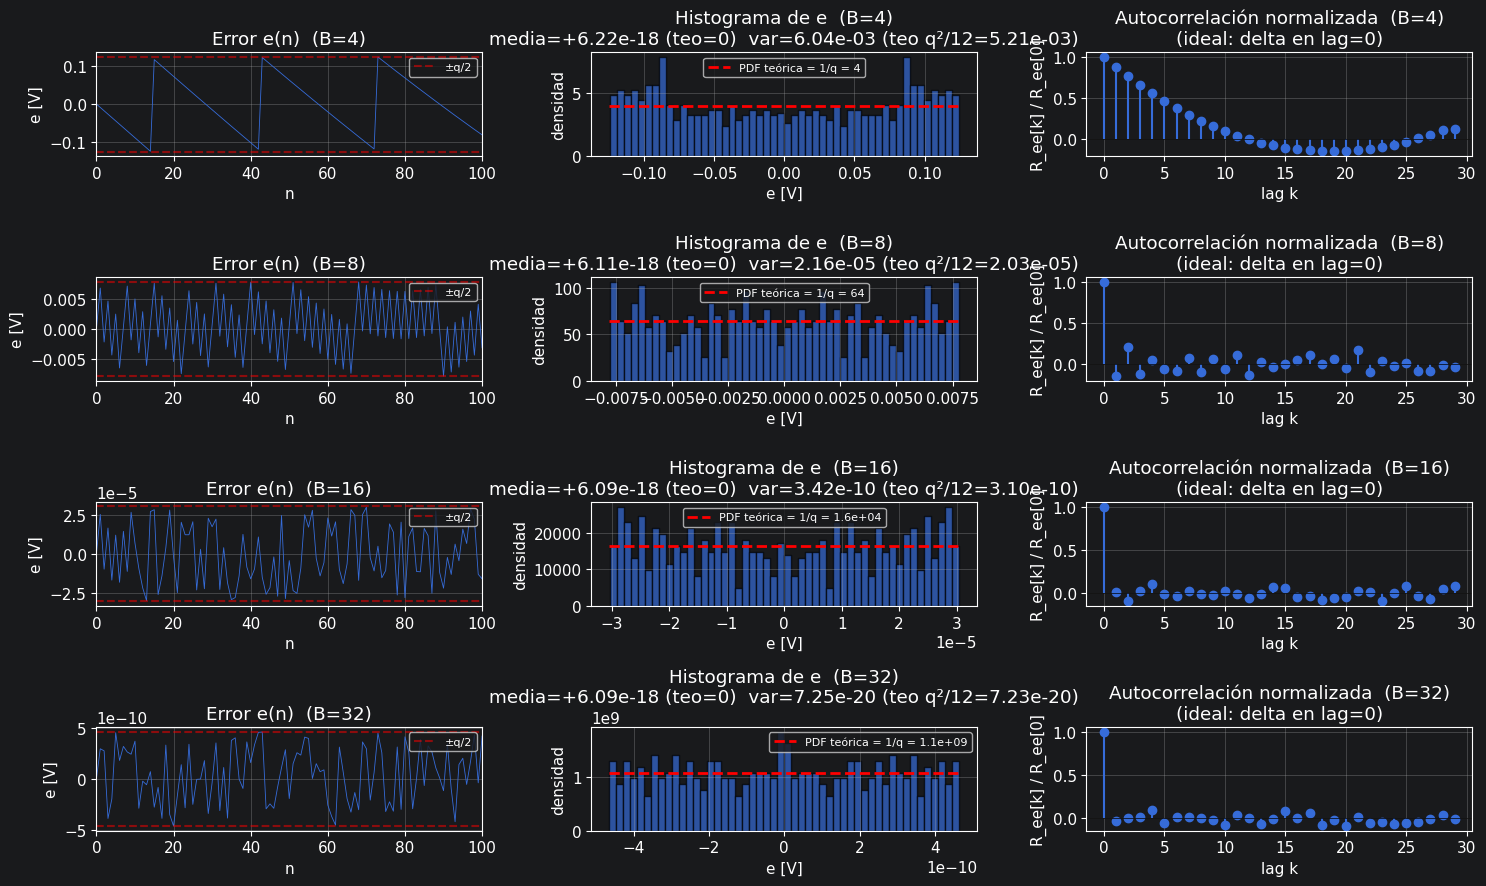

In [8]:
bits_list = [4, 8, 16, 32]

fig, axes = plt.subplots(len(bits_list), 3, figsize=(15, 9))

for i, B in enumerate(bits_list):
    sQ, q = cuantizar(sR, B=B, Vf=2.0)
    e = sQ - sR

    stats = analizar_error(
        e, q,
        ax_serie=axes[i, 0],
        ax_hist =axes[i, 1],
        ax_acorr=axes[i, 2],
        NroBits=f'(B={B})'
    )

    print(f"B={B:2d} | media={stats['media_medida']:+.3e} |  "
          f"var={stats['varianza_medida']:.3e} |  "
          f"q^2 /12={stats['varianza_teorica']:.3e} |   "
          f"lag(0)/N = Potencia = var ={stats['varianza_autocorr']:.3e} |")

plt.tight_layout()
plt.show()

# Analisis de SNR en las señales

### Deduccion de SNR de cuantizacion.

$$SNR = \frac{P_{señal}}{P_{noise}}$$
$$SNR_{db} = 10\log_{10} \left( \frac{P_{señal}}{P_{noise}} \right)$$

### Deduccion de potencias:
$$P_{señal}= V^2_{rms} =\frac{A^2}{2}     (Asumiendo R = 1)$$
$$P_{noise} = var(noise)$$

Como el ruido es uniforme, la varianza de una cuadrada es:

$$var(noise) = \frac{(a - b)^2}{12}$$

como la funcion densidad uniforme esta acotada en +/- q/2

$$var(noise) = \frac{(q/2 - -q/2)^2}{12} = \frac{q}{12}$$

$$P_{noise} = \frac{q^2}{12}$$

### Relacion entre q, Vf y $P_{noise}$

$$q = \frac{V_{FS}}{2^B} = \frac{2\,V_F}{2^B}$$
$$q^2 = \frac{4 \cdot V^2_{FS}}{2^{2B}}$$

entonces:

$$P_{noise} = \frac{4 \cdot V^2_{F}}{12 \cdot 2^2B} = \frac{V^2_{F}}{3 \cdot 2^{2B}}  $$

Si asumimos que se mide a fondo de escala, entonces asumimos que:
$$A = Vf$$

Entonces:
$$P_{señal}=\frac{V_{F}^2}{2}$$

### Deduccion final
$$SNR = \frac{P_{señal}}{P_{noise}} = \frac{\frac{V_{F}^2}{2}}{\frac{V^2_{F}}{3 \cdot 2^{2B}}}$$
$$SNR = \frac{3}{2}\cdot 2^{2B}$$
$$SNR_db = 10log_{10}\left(\frac{3}{2}\right) + 10log_{10}\left(2^{2B}\right)$$
$$SNR_db = 1.76 + B \cdot 10log_{10}\left(2^{2}\right)$$
$$\boxed{SNR_{dB} = 1.76 + 6.02 \cdot B}$$

# Relación del ruido con SNR de cuantización

La fórmula deducida vale bajo las siguientes condiciones:

- La señal a medir es **senoidal a fondo de escala** ($A = V_F$). Si la
  amplitud es menor, hay que aplicar el factor de carga
  $20 \log_{10}(A/V_F)$, que penaliza la SNR.
- El error de cuantización se cumple siempre y cuando la distribucion del error sea uniforme (no es necesaria una buena autocoorelacion para este caso, pero si para que el ruido generado sea blanco)
- El **ruido analógico** de la señal es despreciable frente al de cuantización. Caso contrario, puede ser este el que domine al SNR

En pos del ultimo punto, se analizara el SNR de multipels ADC's y como evolucionan en torno a diferentes ruidos analogicos (se considera que un ruido de 1e-10 ~ 0)

In [9]:
import numpy as np
import matplotlib.pyplot as plt


def experimento_snr(B, sigma, ff=1, fs=1000, n=1000, Vf=2.0):
    _, x = GeneradorSenales.generar_seno(ff=ff, fs=fs, n=n, vmax=Vf)
    x_noisy = GeneradorSenales.generate_noisy_signal(x, sigma=sigma)
    y, q = cuantizar(x_noisy, B=B, Vf=Vf)
    error = (y - x).flatten()

    P_signal = np.mean(x**2)
    P_error  = np.mean(error**2)
    snr_dB   = 10 * np.log10(P_signal / P_error)

    return snr_dB

def ENOB_calculator(snr_dB):
    return (snr_dB - 1.76)/6.02

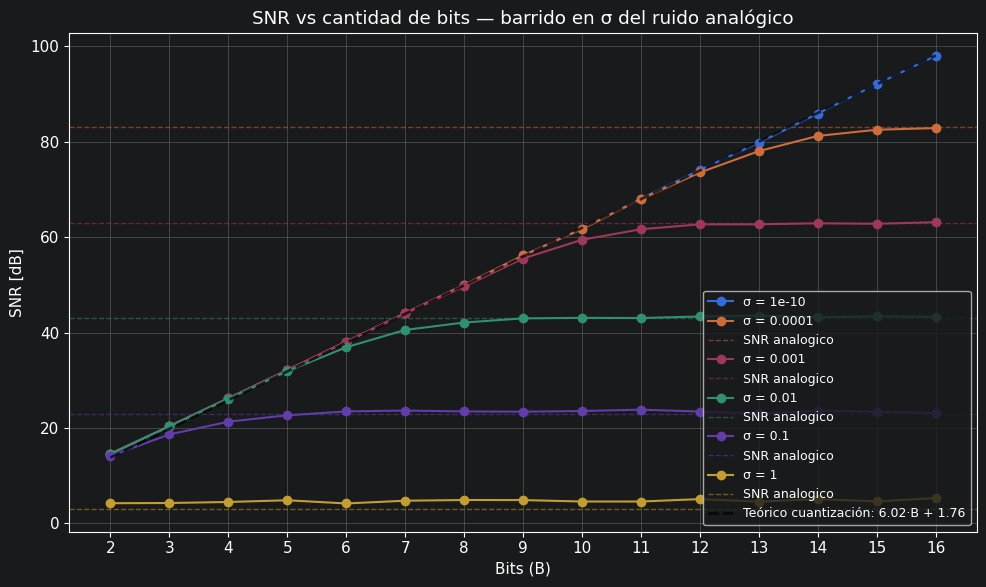

In [10]:
# --- Barrido 2D: B vs sigma ---
Vf = 2
B_range     = np.arange(2, 17)
sigma_range = [1e-10, 1e-4, 1e-3, 1e-2, 1e-1, 1]

fig, ax = plt.subplots(figsize=(10, 6))

# Recta teórica de cuantización pura (6 dB/bit)


for sigma in sigma_range:
    snr_medidos = []
    snr_analogicos = []

    for B in B_range:
        res = experimento_snr(B=B, sigma=sigma, Vf=Vf)
        snr_medidos.append(res)

    snr_analogico = (Vf/sigma)**2 /2
    snr_analogico_db = 10 * np.log10(snr_analogico)

    line, = ax.plot(B_range, snr_medidos, 'o-', label=f'σ = {sigma:g}', lw=1.5)
    if sigma > 1e-5:# saco la de muy bajo ruido por que sino el grafico se ve HORRENDO
        ax.axhline(y=snr_analogico_db, linestyle='--', linewidth=1, alpha=0.5, color=line.get_color(), label= "SNR analogico")

ax.plot(B_range, 6.02*B_range+1.76, 'k--', lw=2,
        label='Teórico cuantización: 6.02·B + 1.76', alpha=0.7)
ax.set_xlabel('Bits (B)')
ax.set_ylabel('SNR [dB]')
ax.set_title('SNR vs cantidad de bits — barrido en σ del ruido analógico')
ax.grid(True, alpha=0.4)
ax.legend(loc='lower right', fontsize=9)
ax.set_xticks(B_range)
plt.tight_layout()
plt.show()


## Conclusiones

Se observa con claridad que el comportamiento del SNR depende de en que punto se opere

- Para valores muy bajos de ruido analógico (σ = 1e-10, curva azul), el
  ruido de cuantización es la única fuente de error apreciable. La curva
  se pega a la recta teórica $6.02 \cdot B + 1.76$ dB y la SNR mejora
  linealmente con cada bit agregado (6 dB/bit).

- A medida que aumenta σ, cada curva muestra una asintota horizonhtal característico:
  inicialmente sigue la recta teórica de cuantización, pero a partir de cierto B se satura en un
  piso horizontal. Ese piso coincide exactamente con el SNR analógico teórico,
  graficado en líneas punteadas.

- De ahi sale el concepto de **ENOB**; la cantidad de bits "efectivos" que tiene un ADC real contaminado con ruido. El resto de bits, si bien siguen estando, seran opacados por el ruido gaussiano aplicado. el ENOB, no es mas que el numero de bits que tendria un ADC con el mismo SNR que el sistema